In [2]:
!kaggle datasets download mahdimashayekhi/used-car-price --unzip

Dataset URL: https://www.kaggle.com/datasets/mahdimashayekhi/used-car-price
License(s): CC-BY-NC-SA-4.0
100% 1.52M/1.52M [00:00<00:00, 47.8MB/s]



# 🚗 Regression Machine Learning Project: Used Car Price Prediction

## 🎯 Project Overview

In this project, you will work with a **real-world used car dataset** to build a complete **Machine Learning Regression workflow**.

Your goal is not only to train a regression model, but to go through the complete process that a Data Scientist would follow when working with a real dataset — starting from understanding and exploring the data, preparing it for Machine Learning, building different regression models, and finally evaluating and comparing their performance.

The main objective is to answer the following question:

> **Can we build a regression model that can accurately predict the price of a used car based on its characteristics?**

You will be responsible for discovering the structure and quality of the data, identifying potential problems, preparing the features appropriately, building different regression models, and using suitable evaluation metrics to understand how well each model performs.

---

## 🔄 Project Workflow

Throughout this assignment, you are expected to follow a complete Machine Learning workflow:

```text
Raw Dataset
     ↓
Data Understanding
     ↓
Exploratory Data Analysis (EDA)
     ↓
Data Cleaning
     ↓
Feature Preparation
     ↓
Train / Test Split
     ↓
Feature Scaling / Transformation
     ↓
Regression Models
     ↓
Model Predictions
     ↓
Regression Evaluation
     ↓
Model Comparison
     ↓
Final Conclusions
```

The important point is that **Machine Learning does not start with fitting a model**.

A good model begins with a good understanding of the data.

---

## 🎯 Target Variable

The main target of this project is:

```text
Price($)
```

Your models should learn the relationship between the available car characteristics and the **selling price of the car**.

You should carefully investigate the available features and decide which features are appropriate for building your regression models.

> ⚠️ **Do not assume that every column in the dataset should automatically be used as a model feature.**

Your decisions should be supported by your analysis of the data.

---

# 🤖 Regression Models

You are required to build and evaluate the following regression approaches:

### 1. Ordinary Least Squares (OLS)

Build a regression model using the **Ordinary Least Squares** approach.

You should understand how the model estimates its coefficients and use it to generate predictions for unseen data.

---

### 2. Stochastic Gradient Descent (SGD)

Build a regression model using **Stochastic Gradient Descent**.

You should prepare the data appropriately for gradient-based optimization and investigate the model's performance.

---

### 3. Polynomial Regression

Build a **Polynomial Regression** model and investigate whether introducing polynomial relationships between features can improve the model's ability to capture patterns in the data.

You should experiment with appropriate polynomial degrees and evaluate the resulting models.

---

# 📊 Model Evaluation

After training the models, you must evaluate their performance using the **regression evaluation metrics covered in the course**.

For every model, calculate the required evaluation metrics on the appropriate dataset and use the results to understand the model's performance.

Your evaluation should help answer questions such as:

* How far are the predictions from the actual prices?
* How large are the prediction errors?
* How well does each model explain the variation in the target?
* Does increasing the polynomial degree improve the model?
* Do different optimization approaches produce different results?

---

# 🔍 Model Comparison

At the end of the project, create a clear comparison between the regression approaches.

For example:

| Model                 | MAE | MSE | RMSE | R² |
| --------------------- | --: | --: | ---: | -: |
| OLS                   |     |     |      |    |
| SGD                   |     |     |      |    |
| Polynomial Regression |     |     |      |    |

Your comparison should not be based only on a single metric.

You should analyze the evaluation results and explain what they tell you about the behavior and performance of each model.

---

# 🧠 Final Goal

By the end of this project, you should be able to demonstrate that you can take a **raw real-world dataset** and transform it into a complete regression solution.

You are expected to demonstrate your ability to:

* Understand an unfamiliar dataset.
* Explore data using EDA.
* Identify and handle data-quality issues.
* Prepare numerical and categorical features.
* Select appropriate features for modeling.
* Split data correctly into training and testing sets.
* Apply appropriate preprocessing.
* Build OLS, SGD, and Polynomial Regression models.
* Generate predictions on unseen data.
* Evaluate regression models using appropriate metrics.
* Compare different regression approaches.
* Interpret your results and communicate your findings.

> **The goal is not to find the model with the lowest error by simply trying different combinations. The goal is to understand the complete process and justify your decisions using evidence from the data.**

---

## 🚀 Your Mission

> **Explore the data. Clean it. Understand it. Build it. Evaluate it. Explain it.**

Treat this assignment as a **real Machine Learning project**, not as a collection of isolated coding exercises.


## 1. Import Libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Raw Dataset

In [4]:
df = pd.read_csv('car_price_dataset.csv')

## 3. Data Understanding

In [5]:
df.head()

,Brand,Model,Year,CarAge,Condition,Mileage(km),EngineSize(L),FuelType,Horsepower,Torque,...,Color,Interior,Options,City,AccidentHistory,Insurance,RegistrationStatus,FuelEfficiency(L/100km),PricePerKm,Price($)
0,Porsche,Panamera,2008,17,Used,256395,3.3,Gasoline,513,395,...,White,Cloth,"Navigation, Cruise Control, Heated Seats, Blue...",Tehran,No,Valid,Incomplete,11.96,0.05,13884
1,Audi,A6,2023,2,Used,20433,2.2,Diesel,302,270,...,Black,Cloth,"Parking Sensors, Cruise Control, Touchscreen",Berlin,Yes,Expired,Incomplete,8.74,1.90,38888
2,BMW,X5,2022,3,Used,52328,3.2,Gasoline,400,388,...,Gray,Leather,"Touchscreen, Bluetooth, Cruise Control, Naviga...",Tokyo,Yes,Valid,Complete,15.68,0.63,33074
3,Hyundai,Tucson,2019,6,Used,91878,1.6,Hybrid,187,219,...,Silver,Cloth,"Sunroof, Rear Camera, Bluetooth, Parking Senso...",Delhi,No,Expired,Complete,9.45,0.14,12966
4,Fiat,500,2012,13,Damaged,192331,1.1,Gasoline,90,112,...,Red,Leather,"Heated Seats, Touchscreen",Delhi,No,Valid,Complete,7.16,0.01,2670


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Brand                    50000 non-null  object 
 1   Model                    50000 non-null  object 
 2   Year                     50000 non-null  int64  
 3   CarAge                   50000 non-null  int64  
 4   Condition                50000 non-null  object 
 5   Mileage(km)              50000 non-null  int64  
 6   EngineSize(L)            50000 non-null  float64
 7   FuelType                 50000 non-null  object 
 8   Horsepower               50000 non-null  int64  
 9   Torque                   50000 non-null  int64  
 10  Transmission             50000 non-null  object 
 11  DriveType                50000 non-null  object 
 12  BodyType                 50000 non-null  object 
 13  Doors                    50000 non-null  int64  
 14  Seats                 

In [7]:
df.describe()

,Year,CarAge,Mileage(km),EngineSize(L),Horsepower,Torque,Doors,Seats,FuelEfficiency(L/100km),PricePerKm,Price($)
count,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,47541.000000,50000.000000
mean,2014.99852,10.00148,150048.081460,2.127286,279.731440,326.660080,4.139060,4.721720,9.346222,0.305946,15780.750960
std,6.06553,6.06553,91085.992898,1.139203,153.703605,137.000291,0.979276,1.080418,4.072040,0.855643,16838.548646
min,2005.00000,0.00000,0.000000,0.000000,65.000000,16.000000,2.000000,2.000000,0.000000,0.000000,1249.000000
25%,2010.00000,5.00000,71548.000000,1.400000,179.000000,227.000000,4.000000,5.000000,7.530000,0.020000,4943.000000
50%,2015.00000,10.00000,150478.000000,2.000000,240.000000,307.000000,4.000000,5.000000,9.680000,0.060000,10063.000000
75%,2020.00000,15.00000,228461.500000,2.800000,386.000000,415.000000,5.000000,5.000000,11.980000,0.220000,19745.250000
max,2025.00000,20.00000,320262.000000,6.000000,905.000000,850.000000,5.000000,7.000000,21.180000,34.560000,131850.000000


In [8]:
df.nunique()

,0
Brand,17
Model,43
Year,21
CarAge,21
Condition,3
Mileage(km),44835
EngineSize(L),53
FuelType,4
Horsepower,623
Torque,744


## 4. Exploratory Data Analysis (EDA)


In [9]:
TARGET = "Price($)"
df[TARGET].describe()

,Price($)
count,50000.000000
mean,15780.750960
std,16838.548646
min,1249.000000
25%,4943.000000
50%,10063.000000
75%,19745.250000
max,131850.000000


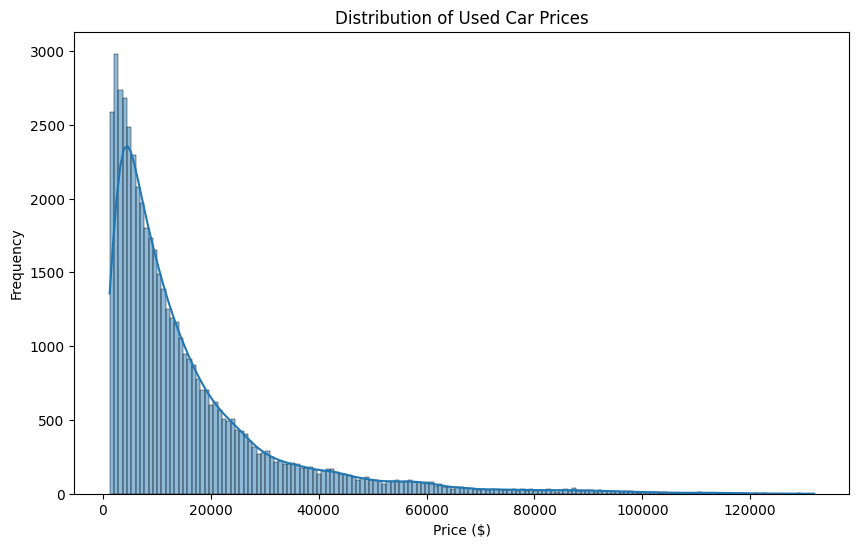

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df[TARGET].dropna(), kde=True)
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Used Car Prices")
plt.show()

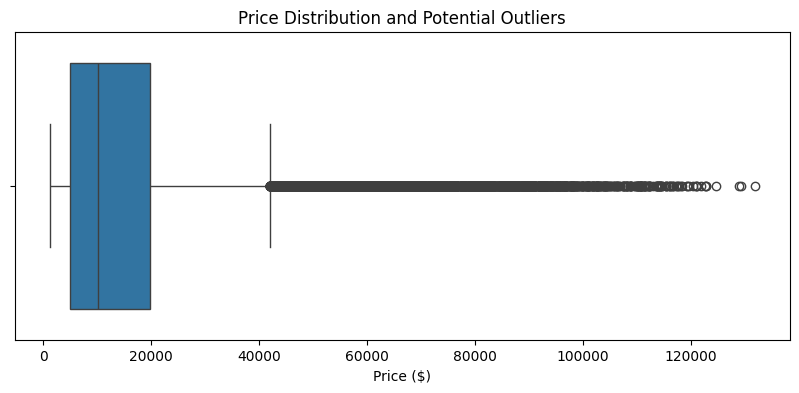

In [11]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df[TARGET])
plt.xlabel("Price ($)")
plt.title("Price Distribution and Potential Outliers")
plt.show()

## 5. Data Cleaning

In [12]:
df2 = df.copy()

In [13]:
df2.isna().sum()

,0
Brand,0
Model,0
Year,0
CarAge,0
Condition,0
Mileage(km),0
EngineSize(L),0
FuelType,0
Horsepower,0
Torque,0


In [14]:
df2['PricePerKm'].describe()

,PricePerKm
count,47541.000000
mean,0.305946
std,0.855643
min,0.000000
25%,0.020000
50%,0.060000
75%,0.220000
max,34.560000


In [15]:
df2['PricePerKm'].fillna(df2['PricePerKm'].mean(), inplace=True)

/tmp/ipykernel_761/1535667546.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['PricePerKm'].fillna(df2['PricePerKm'].mean(), inplace=True)


In [16]:
df2.duplicated().sum()

np.int64(0)

In [17]:
df[df2['Price($)'] <= 0]

,Brand,Model,Year,CarAge,Condition,Mileage(km),EngineSize(L),FuelType,Horsepower,Torque,...,Color,Interior,Options,City,AccidentHistory,Insurance,RegistrationStatus,FuelEfficiency(L/100km),PricePerKm,Price($)


In [18]:
df2.nunique()

,0
Brand,17
Model,43
Year,21
CarAge,21
Condition,3
Mileage(km),44835
EngineSize(L),53
FuelType,4
Horsepower,623
Torque,744


In [19]:
categorical_cols = ['Brand', 'Condition', 'FuelType', 'Transmission', 'DriveType', 'BodyType', 'Doors', 'Seats', 'Color', 'Interior', 'City', 'AccidentHistory', 'Insurance', 'RegistrationStatus']

df2[categorical_cols] = df2[categorical_cols].astype('category')

In [20]:
df2[categorical_cols].dtypes

,0
Brand,category
Condition,category
FuelType,category
Transmission,category
DriveType,category
BodyType,category
Doors,category
Seats,category
Color,category
Interior,category


## 6. Feature Selection

In [21]:
X = df2.drop(columns=[TARGET])
y = df2[TARGET]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)


Numerical features: ['Year', 'CarAge', 'Mileage(km)', 'EngineSize(L)', 'Horsepower', 'Torque', 'FuelEfficiency(L/100km)', 'PricePerKm']
Categorical features: ['Brand', 'Model', 'Condition', 'FuelType', 'Transmission', 'DriveType', 'BodyType', 'Doors', 'Seats', 'Color', 'Interior', 'Options', 'City', 'AccidentHistory', 'Insurance', 'RegistrationStatus']


## 7. Train / Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 40000
Testing samples: 10000


## 8. Preprocessing Pipeline

In [23]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


# 9. Model 1 — Ordinary Least Squares (OLS)

In [24]:
ols_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

ols_model.fit(X_train, y_train)
ols_pred = ols_model.predict(X_test)

# 10. Model 2 — Stochastic Gradient Descent (SGD)

In [25]:
sgd_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SGDRegressor(
        loss="squared_error",
        penalty="l2",
        max_iter=2000,
        tol=1e-3,
        random_state=RANDOM_STATE
    ))
])

sgd_model.fit(X_train, y_train)
sgd_pred = sgd_model.predict(X_test)

# 11. Model 3 — Polynomial Regression

In [26]:
polynomial_results = []
polynomial_models = {}

for degree in [2, 3]:
    polynomial_numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("polynomial", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler())
    ])

    polynomial_preprocessor = ColumnTransformer([
        ("num", polynomial_numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    model = Pipeline([
        ("preprocessor", polynomial_preprocessor),
        ("model", LinearRegression())
    ])

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    polynomial_results.append({
        "Degree": degree,
        "MAE": mean_absolute_error(y_test, predictions),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(y_test, predictions)
    })
    polynomial_models[degree] = (model, predictions)

polynomial_results_df = pd.DataFrame(polynomial_results)

best_degree = int(polynomial_results_df.loc[polynomial_results_df["RMSE"].idxmin(), "Degree"])
polynomial_model, polynomial_pred = polynomial_models[best_degree]
polynomial_results_df


,Degree,MAE,MSE,RMSE,R²
0,2,2584.807902,1.898666e+07,4357.368913,0.932001
1,3,1774.667490,1.065641e+07,3264.416202,0.961835


# 12. Regression Evaluation

In [27]:
def evaluate_model(name, y_true, predictions):
    mse = mean_squared_error(y_true, predictions)
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, predictions),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(y_true, predictions)
    }

results_df = pd.DataFrame([
    evaluate_model("OLS", y_test, ols_pred),
    evaluate_model("SGD", y_test, sgd_pred),
    evaluate_model(f"Polynomial Regression (Degree {best_degree})", y_test, polynomial_pred)
])

results_df.sort_values("RMSE")


,Model,MAE,MSE,RMSE,R²
2,Polynomial Regression (Degree 3),1774.667490,1.065641e+07,3264.416202,0.961835
0,OLS,4597.877391,4.828682e+07,6948.871842,0.827066
1,SGD,4522.151249,4.918641e+07,7013.302045,0.823844


## 13. Model Comparison

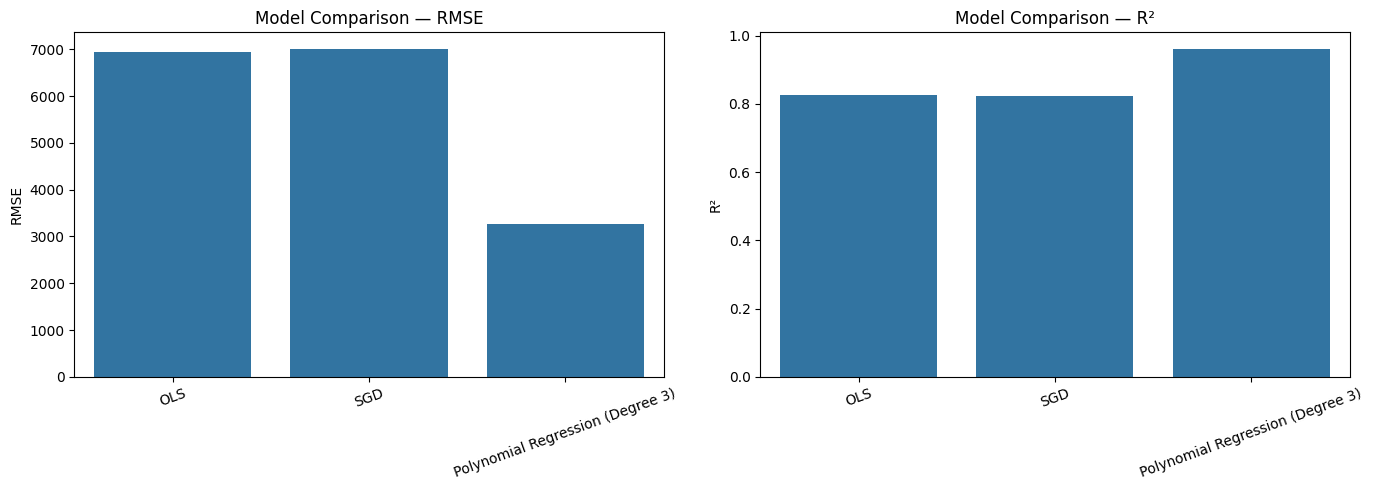

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[0])
axes[0].set_title("Model Comparison — RMSE")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=results_df, x="Model", y="R²", ax=axes[1])
axes[1].set_title("Model Comparison — R²")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 14. Actual vs Predicted Prices

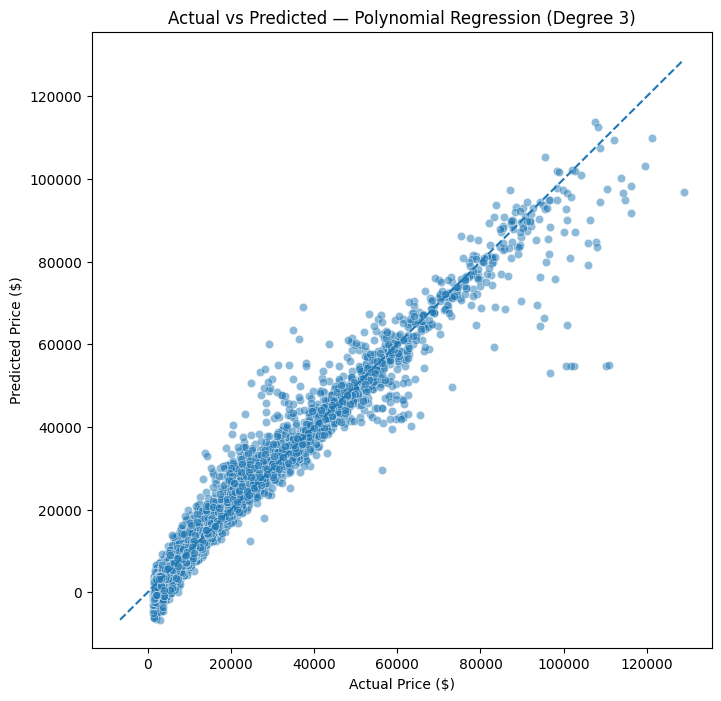

In [29]:
best_model_name = results_df.loc[results_df["RMSE"].idxmin(), "Model"]
prediction_map = {
    "OLS": ols_pred,
    "SGD": sgd_pred,
    f"Polynomial Regression (Degree {best_degree})": polynomial_pred
}
best_predictions = prediction_map[best_model_name]

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.5)

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.show()


## 15. Residual Analysis

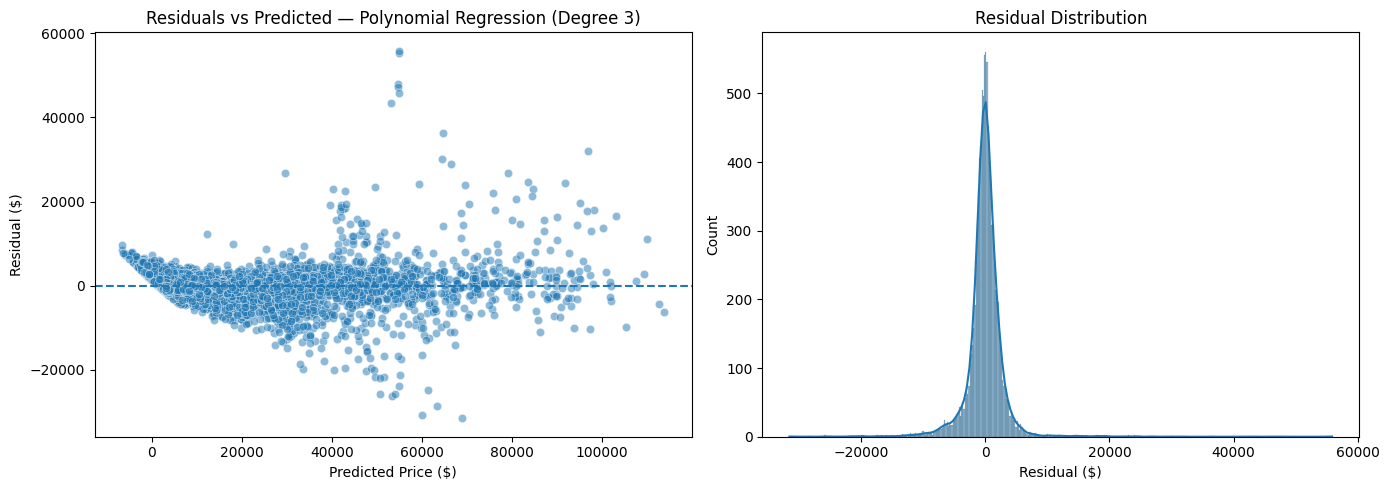

In [30]:
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=best_predictions, y=residuals, alpha=0.5, ax=axes[0])
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Predicted Price ($)")
axes[0].set_ylabel("Residual ($)")
axes[0].set_title(f"Residuals vs Predicted — {best_model_name}")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_xlabel("Residual ($)")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()
